# Análisis Exploratorio Banda 9

## Obtención del dataset

In [2]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor

# Ruta donde están almacenados los archivos .npy
ruta_archivos = "/home/jhon/bandas/banda9/imagenes_validas" # Cambia por tu ruta real
# Listar todos los archivos en la ruta
archivos = os.listdir(ruta_archivos)

# Función para procesar un archivo individual (sin guardar la matriz radiancia)
def procesar_archivo(archivo):
    if archivo.endswith(".npy") and archivo.startswith("RadFC_"):
        try:
            nombre = archivo.replace("RadFC_", "").replace("_Rad9.npy", "")
            fecha_str = nombre[:12]  # 'YYYYMMDDHHMM'
            fecha_datetime = datetime.strptime(fecha_str, "%Y%m%d%H%M")
            fecha = fecha_datetime
            mes = fecha_datetime.month
            hora = fecha_datetime.strftime("%H:%M")
            hora_num = fecha_datetime.hour
            ruta_completa = os.path.join(ruta_archivos, archivo)
            radiancia = np.load(ruta_completa).astype(np.float32)
            if radiancia.shape == (920, 920):
                return {
                    "fecha": fecha,
                    "mes": mes,
                    "hora": hora,
                    "hora_num": hora_num,
                    "archivo": archivo,
                    "media": np.mean(radiancia),
                    "varianza": np.var(radiancia),
                    "desviacion_estandar": np.std(radiancia),
                    "minimo": np.min(radiancia),
                    "maximo": np.max(radiancia),
                    "mediana": np.median(radiancia),
                }
            else:
                print(f"Dimensiones incorrectas en: {archivo}")
        except Exception as e:
            print(f"Error procesando {archivo}: {e}")
    return None

# Procesar archivos en paralelo
def procesar_archivos_en_paralelo(archivos, num_workers=os.cpu_count()):
    datos = []
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        resultados = executor.map(procesar_archivo, archivos)
        for resultado in resultados:
            if resultado is not None:
                datos.append(resultado)
    return datos

# Ejecutar el procesamiento en paralelo
datos = procesar_archivos_en_paralelo(archivos)

# Crear el DataFrame y establecer 'fecha' como índice
df_imagenes = pd.DataFrame(datos)

# Convertir la columna 'fecha' a tipo datetime y establecerla como índice
df_imagenes["fecha"] = pd.to_datetime(df_imagenes["fecha"])
df_imagenes = df_imagenes.set_index("fecha")

# Ordenar el DataFrame por índice (fecha)
df_imagenes.sort_index(inplace=True)

# Imprimir las primeras filas
print(df_imagenes.head())

                     mes   hora  hora_num                        archivo  \
fecha                                                                      
2024-01-01 00:00:00    1  00:00         0  RadFC_20240101000020_Rad9.npy   
2024-01-01 01:00:00    1  01:00         1  RadFC_20240101010020_Rad9.npy   
2024-01-01 02:00:00    1  02:00         2  RadFC_20240101020020_Rad9.npy   
2024-01-01 03:00:00    1  03:00         3  RadFC_20240101030020_Rad9.npy   
2024-01-01 04:00:00    1  04:00         4  RadFC_20240101040020_Rad9.npy   

                        media  varianza  desviacion_estandar    minimo  \
fecha                                                                    
2024-01-01 00:00:00  8.170711  7.833383             2.798818  0.618903   
2024-01-01 01:00:00  8.263684  7.405015             2.721216  0.754137   
2024-01-01 02:00:00  8.344071  6.978974             2.641775  0.776676   
2024-01-01 03:00:00  8.418755  6.463727             2.542386  0.618903   
2024-01-01 04:00:00  8.

| fecha                | mes | hora  | hora_num | archivo                            | media    | varianza | desviacion_estandar | minimo   | maximo    | mediana  |
|----------------------|-----|-------|----------|------------------------------------|----------|----------|---------------------|----------|-----------|----------|
| 2024-01-01 00:00:00 | 1   | 00:00 | 0        | RadFC_20240101000020_Rad9.npy     | 8.170711 | 7.833383 | 2.798818           | 0.618903 | 13.195722 | 8.372354 |
| 2024-01-01 01:00:00 | 1   | 01:00 | 1        | RadFC_20240101010020_Rad9.npy     | 8.263684 | 7.405014 | 2.721215           | 0.754137 | 13.218261 | 8.439971 |
| 2024-01-01 02:00:00 | 1   | 02:00 | 2        | RadFC_20240101020020_Rad9.npy     | 8.344069 | 6.978976 | 2.641775           | 0.776676 | 13.037948 | 8.462510 |
| 2024-01-01 03:00:00 | 1   | 03:00 | 3        | RadFC_20240101030020_Rad9.npy     | 8.418756 | 6.463727 | 2.542386           | 0.618903 | 13.173182 | 8.417432 |
| 2024-01-01 04:00:00 | 1   | 04:00 | 4        | RadFC_20240101040020_Rad9.npy     | 8.492280 | 5.929727 | 2.435103           | 0.776676 | 13.376034 | 8.372354 |


A partir de las imágenes obtenidas, se construyó un conjunto de datos (dataset) con las siguientes columnas: fecha, mes, hora, nombre del archivo, media, varianza, desviación estándar, mínimo, máximo y mediana. Las variables estadísticas fueron calculadas a partir de los valores de radiancia presentes en cada imagen, con el propósito de realizar un análisis exploratorio de los datos.

Asimismo, se incorporó una columna denominada archivo, que almacena los nombres de los archivos correspondientes a las imágenes descargadas. Esta decisión se tomó para evitar la generación de una matriz individual por cada imagen, ya que el tamaño de cada una (920x920 píxeles) representa una carga considerable en términos de recursos computacionales, lo cual podría comprometer el rendimiento del sistema o incluso provocar su bloqueo.

In [3]:
df_imagenes.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8697 entries, 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mes                  8697 non-null   int64  
 1   hora                 8697 non-null   object 
 2   hora_num             8697 non-null   int64  
 3   archivo              8697 non-null   object 
 4   media                8697 non-null   float32
 5   varianza             8697 non-null   float32
 6   desviacion_estandar  8697 non-null   float32
 7   minimo               8697 non-null   float32
 8   maximo               8697 non-null   float32
 9   mediana              8697 non-null   float32
dtypes: float32(6), int64(2), object(2)
memory usage: 543.6+ KB


Script para visualizar las imágenes en un día específico

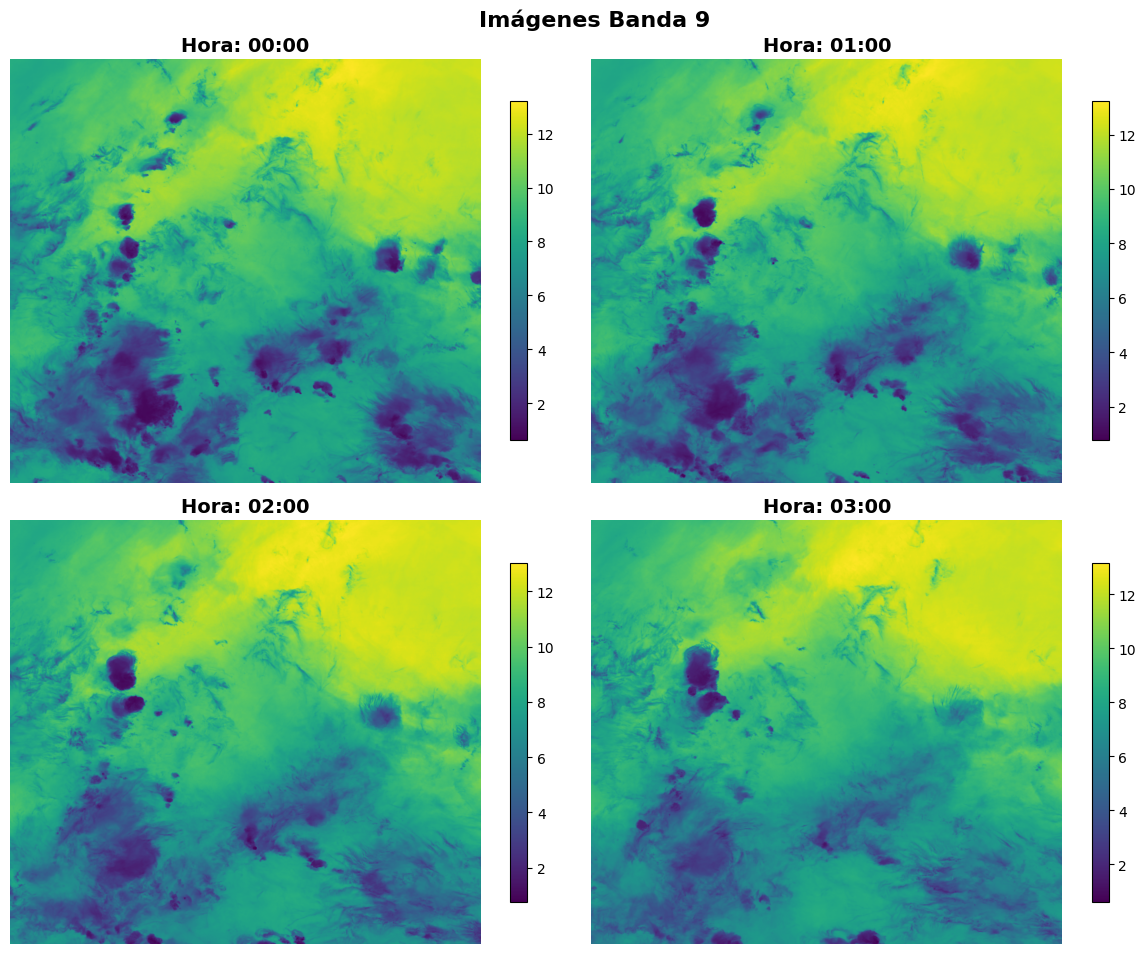

Mostrando las primeras 4 horas del día 2024-01-01
Horas mostradas: ['00:00', '01:00', '02:00', '03:00']


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Filtrar las primeras 4 horas del primer día disponible
primer_dia = df_imagenes.index.normalize().min()  # Obtener el primer día
primeras_horas = df_imagenes[df_imagenes.index.normalize() == primer_dia].head(4)

if len(primeras_horas) == 0:
    print("No hay imágenes disponibles para el primer día")
else:
    # Crear figura 2x2
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, (idx, fila) in enumerate(primeras_horas.iterrows()):
        # Cargar la imagen
        ruta_completa = os.path.join(ruta_archivos, fila['archivo'])
        matriz = np.load(ruta_completa)
        
        # Plotear en el subplot correspondiente
        ax = axes[i]
        im = ax.imshow(matriz, cmap='viridis', aspect='auto')
        
        # Formatear hora para el título
        hora_formateada = idx.strftime("%H:%M")
        
        # Título de cada subplot
        ax.set_title(f'Hora: {hora_formateada}', fontsize=14, fontweight='bold')
        ax.axis('off')
        
        # Agregar barra de color para cada imagen
        plt.colorbar(im, ax=ax, shrink=0.8)
    
    # Título principal
    fig.suptitle('Imágenes Banda 9', fontsize=16, fontweight='bold', y=0.95)
    
    # Ajustar layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()
    
    print(f"Mostrando las primeras 4 horas del día {primer_dia.strftime('%Y-%m-%d')}")
    print("Horas mostradas:", [idx.strftime("%H:%M") for idx in primeras_horas.index])

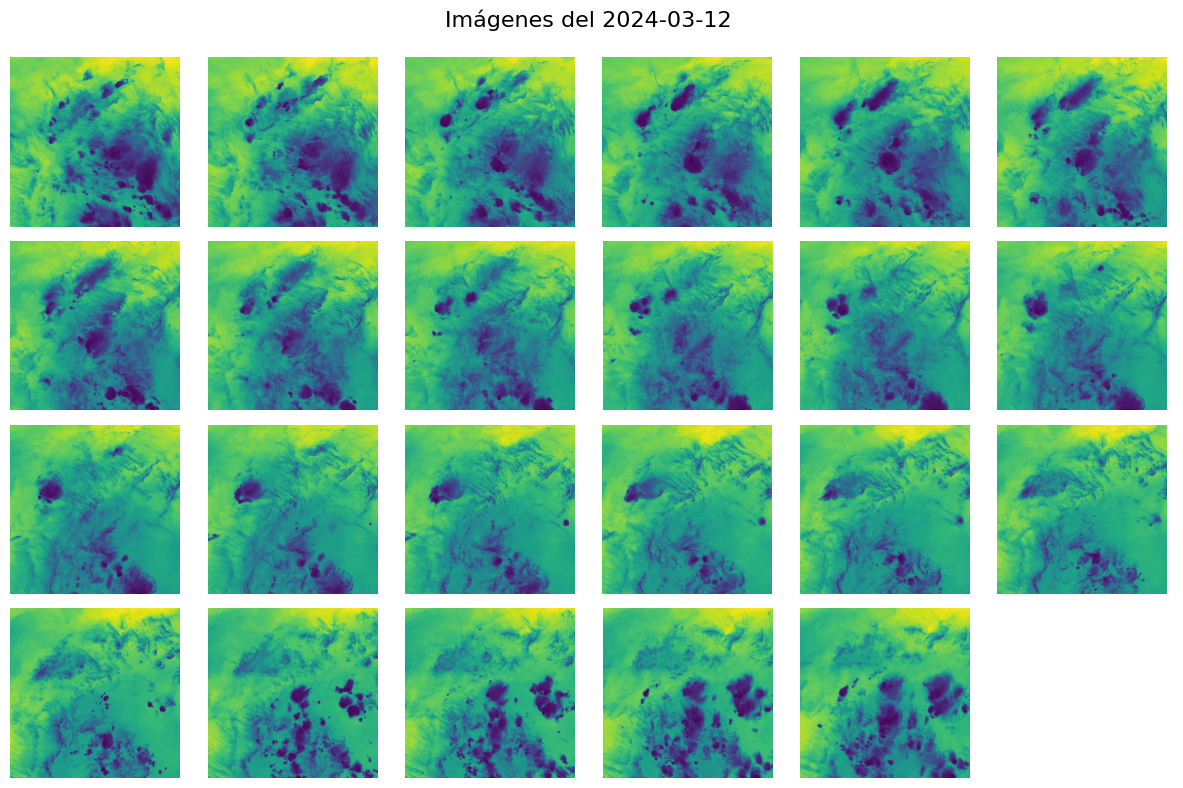

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
ruta_archivos = "/home/jhon/bandas/banda9/imagenes_validas"
dia_especifico = "2024-03-12"

# Selecciona archivos del día específico (formato: RadFC_YYYYMMDDHHMMxx_Rad9.npy)
archivos_dia = []
for archivo in os.listdir(ruta_archivos):
    if archivo.startswith("RadFC_") and archivo.endswith("_Rad9.npy"):
        fecha_archivo = archivo[6:14]  # YYYYMMDD
        if fecha_archivo == dia_especifico.replace("-", ""):
            archivos_dia.append(archivo)

if not archivos_dia:
    print(f"No se encontraron imágenes para el día {dia_especifico}")
else:
    archivos_dia.sort()
    total = len(archivos_dia)
    ncols = 6
    nrows = int(np.ceil(total / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))
    axes = axes.flatten()
    for i, archivo in enumerate(archivos_dia):
        ruta_completa = os.path.join(ruta_archivos, archivo)
        matriz = np.load(ruta_completa)
        ax = axes[i]
        im = ax.imshow(matriz, cmap='viridis')
        ax.axis('off')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'Imágenes del {dia_especifico}', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)

### Análisis Exploratorio
Esta sección presenta el análisis exploratorio de las imágenes satelitales, comenzando con la visualización de ejemplos representativos y el estudio de los patrones de radiancia (valores mínimo, máximo y promedio) a través de diferentes escalas temporales: mensual y horaria. Como parte del proceso, se generaron mapas de calor que relacionan el promedio de radiancia con la hora y el mes, facilitando la detección de valores atípicos. Adicionalmente, se realizó un análisis de autocorrelación para determinar el número óptimo de frames temporales anteriores que pueden utilizarse como entrada en los modelos ConvLSTM2D. El estudio concluye con un análisis exhaustivo de la distribución temporal de la radiancia, sentando las bases para el desarrollo posterior de modelos de deep learning.

* Mínimo de radiancia

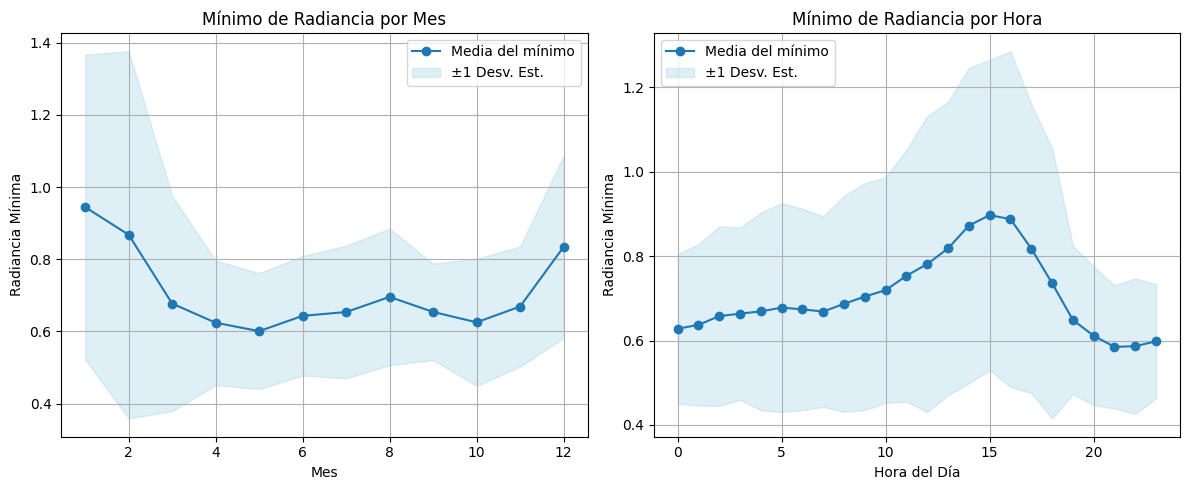

In [5]:
# ----- RESUMEN POR MES -----
resumen_min_mes = df_imagenes.groupby('mes')['minimo'].agg(['mean', 'std']).reset_index()
resumen_min_mes.rename(columns={'mean': 'media', 'std': 'desviacion_estandar'}, inplace=True)

# ----- RESUMEN POR HORA -----
resumen_min_hora = df_imagenes.groupby('hora_num')['minimo'].agg(['mean', 'std']).reset_index()
resumen_min_hora.rename(columns={'mean': 'media', 'std': 'desviacion_estandar'}, inplace=True)

# ----- GRAFICAR -----
plt.figure(figsize=(12, 5))

# Por mes
plt.subplot(1, 2, 1)
plt.plot(resumen_min_mes['mes'], resumen_min_mes['media'], marker='o', label='Media del mínimo')
plt.fill_between(resumen_min_mes['mes'],
                 resumen_min_mes['media'] - resumen_min_mes['desviacion_estandar'],
                 resumen_min_mes['media'] + resumen_min_mes['desviacion_estandar'],
                 color='lightblue', alpha=0.4, label='±1 Desv. Est.')
plt.title('Mínimo de Radiancia por Mes')
plt.xlabel('Mes')
plt.ylabel('Radiancia Mínima')
plt.legend()
plt.grid(True)

# Por hora
plt.subplot(1, 2, 2)
plt.plot(resumen_min_hora['hora_num'], resumen_min_hora['media'], marker='o', label='Media del mínimo')
plt.fill_between(resumen_min_hora['hora_num'],
                 resumen_min_hora['media'] - resumen_min_hora['desviacion_estandar'],
                 resumen_min_hora['media'] + resumen_min_hora['desviacion_estandar'],
                 color='lightblue', alpha=0.4, label='±1 Desv. Est.')
plt.title('Mínimo de Radiancia por Hora')
plt.xlabel('Hora del Día')
plt.ylabel('Radiancia Mínima')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

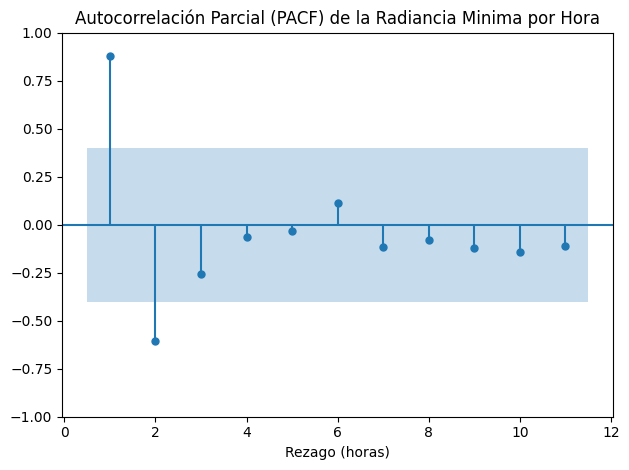

In [6]:
from statsmodels.graphics.tsaplots import plot_pacf

# Autocorrelación parcial para la media por hora
plt.figure(figsize=(8, 4))
plot_pacf(resumen_min_hora['media'], lags=11, method='ywm', zero=False)
plt.title('Autocorrelación Parcial (PACF) de la Radiancia Minima por Hora')
plt.xlabel('Rezago (horas)')
plt.tight_layout()
plt.show()

* Máximo de radiancia

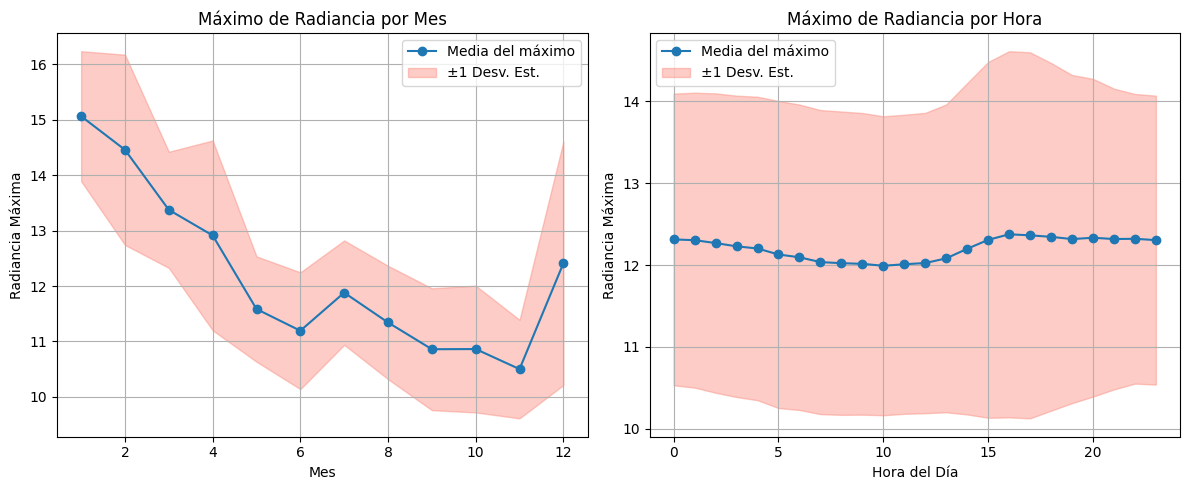

In [8]:
# ----- RESUMEN POR MES -----
resumen_max_mes = df_imagenes.groupby('mes')['maximo'].agg(['mean', 'std']).reset_index()
resumen_max_mes.rename(columns={'mean': 'media', 'std': 'desviacion_estandar'}, inplace=True)

# ----- RESUMEN POR HORA -----
resumen_max_hora = df_imagenes.groupby('hora_num')['maximo'].agg(['mean', 'std']).reset_index()
resumen_max_hora.rename(columns={'mean': 'media', 'std': 'desviacion_estandar'}, inplace=True)

# ----- GRAFICAR -----
plt.figure(figsize=(12, 5))

# Por mes
plt.subplot(1, 2, 1)
plt.plot(resumen_max_mes['mes'], resumen_max_mes['media'], marker='o', label='Media del máximo')
plt.fill_between(resumen_max_mes['mes'],
                 resumen_max_mes['media'] - resumen_max_mes['desviacion_estandar'],
                 resumen_max_mes['media'] + resumen_max_mes['desviacion_estandar'],
                 color='salmon', alpha=0.4, label='±1 Desv. Est.')
plt.title('Máximo de Radiancia por Mes')
plt.xlabel('Mes')
plt.ylabel('Radiancia Máxima')
plt.legend()
plt.grid(True)

# Por hora
plt.subplot(1, 2, 2)
plt.plot(resumen_max_hora['hora_num'], resumen_max_hora['media'], marker='o', label='Media del máximo')
plt.fill_between(resumen_max_hora['hora_num'],
                 resumen_max_hora['media'] - resumen_max_hora['desviacion_estandar'],
                 resumen_max_hora['media'] + resumen_max_hora['desviacion_estandar'],
                 color='salmon', alpha=0.4, label='±1 Desv. Est.')
plt.title('Máximo de Radiancia por Hora')
plt.xlabel('Hora del Día')
plt.ylabel('Radiancia Máxima')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

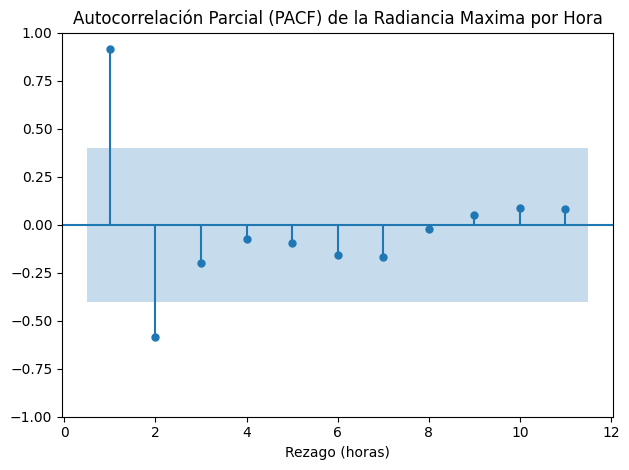

In [9]:
from statsmodels.graphics.tsaplots import plot_pacf

# Autocorrelación parcial para la media por hora
plt.figure(figsize=(8, 4))
plot_pacf(resumen_max_hora['media'], lags=11, method='ywm', zero=False)
plt.title('Autocorrelación Parcial (PACF) de la Radiancia Maxima por Hora')
plt.xlabel('Rezago (horas)')
plt.tight_layout()
plt.show()

* Promedio de radiancia

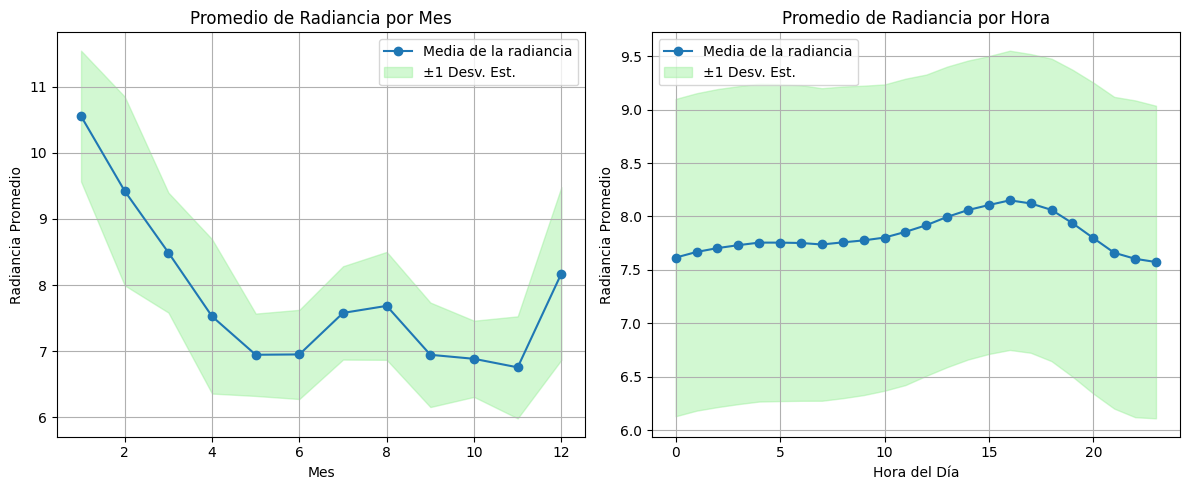

In [10]:
# ----- RESUMEN POR MES -----
resumen_media_mes = df_imagenes.groupby('mes')['media'].agg(['mean', 'std']).reset_index()
resumen_media_mes.rename(columns={'mean': 'media', 'std': 'desviacion_estandar'}, inplace=True)

# ----- RESUMEN POR HORA -----
resumen_media_hora = df_imagenes.groupby('hora_num')['media'].agg(['mean', 'std']).reset_index()
resumen_media_hora.rename(columns={'mean': 'media', 'std': 'desviacion_estandar'}, inplace=True)

# ----- GRAFICAR -----
plt.figure(figsize=(12, 5))

# Por mes
plt.subplot(1, 2, 1)
plt.plot(resumen_media_mes['mes'], resumen_media_mes['media'], marker='o', label='Media de la radiancia')
plt.fill_between(resumen_media_mes['mes'],
                 resumen_media_mes['media'] - resumen_media_mes['desviacion_estandar'],
                 resumen_media_mes['media'] + resumen_media_mes['desviacion_estandar'],
                 color='lightgreen', alpha=0.4, label='±1 Desv. Est.')
plt.title('Promedio de Radiancia por Mes')
plt.xlabel('Mes')
plt.ylabel('Radiancia Promedio')
plt.legend()
plt.grid(True)

# Por hora
plt.subplot(1, 2, 2)
plt.plot(resumen_media_hora['hora_num'], resumen_media_hora['media'], marker='o', label='Media de la radiancia')
plt.fill_between(resumen_media_hora['hora_num'],
                 resumen_media_hora['media'] - resumen_media_hora['desviacion_estandar'],
                 resumen_media_hora['media'] + resumen_media_hora['desviacion_estandar'],
                 color='lightgreen', alpha=0.4, label='±1 Desv. Est.')
plt.title('Promedio de Radiancia por Hora')
plt.xlabel('Hora del Día')
plt.ylabel('Radiancia Promedio')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

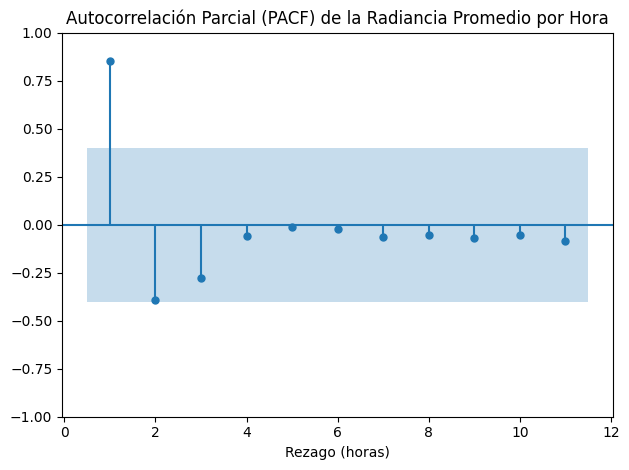

In [11]:
from statsmodels.graphics.tsaplots import plot_pacf

# Autocorrelación parcial para la media por hora
plt.figure(figsize=(8, 4))
plot_pacf(resumen_media_hora['media'], lags=11, method='ywm', zero=False)
plt.title('Autocorrelación Parcial (PACF) de la Radiancia Promedio por Hora')
plt.xlabel('Rezago (horas)')
plt.tight_layout()
plt.show()

* Mapa de calor

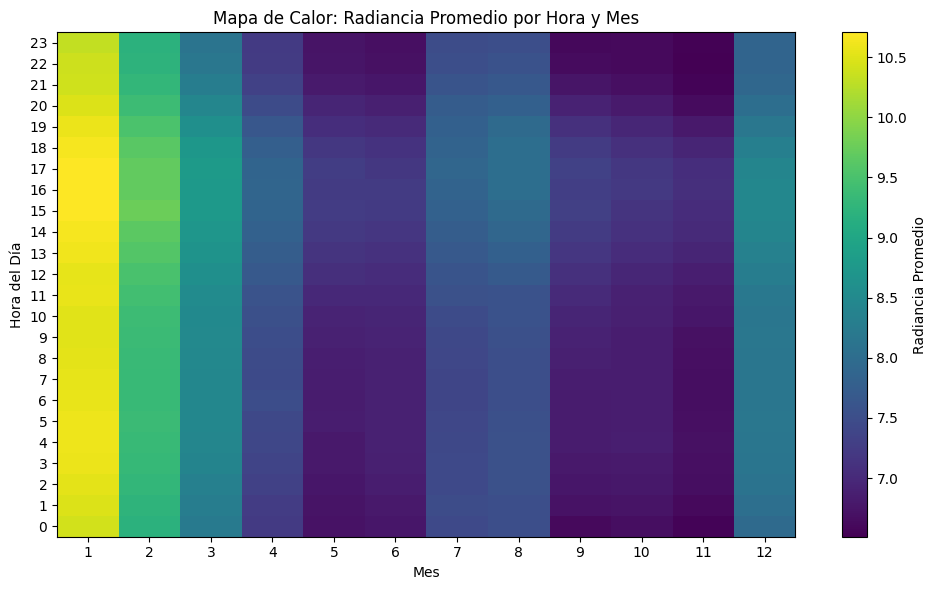

In [36]:
# Crear tabla pivote (hora vs mes)
pivot_heatmap = df_imagenes.pivot_table(
    values='media',
    index='hora_num',
    columns='mes',
    aggfunc='mean'
)

# Heatmap
plt.figure(figsize=(10, 6))
plt.imshow(pivot_heatmap, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Radiancia Promedio')
plt.title('Mapa de Calor: Radiancia Promedio por Hora y Mes')
plt.xlabel('Mes')
plt.ylabel('Hora del Día')
plt.xticks(ticks=np.arange(0, 12), labels=[str(m) for m in range(1, 13)])
plt.yticks(ticks=np.arange(0, 24), labels=[str(h) for h in range(0, 24)])
plt.tight_layout()
plt.show()

* Línea temporal de la radiancia promedio

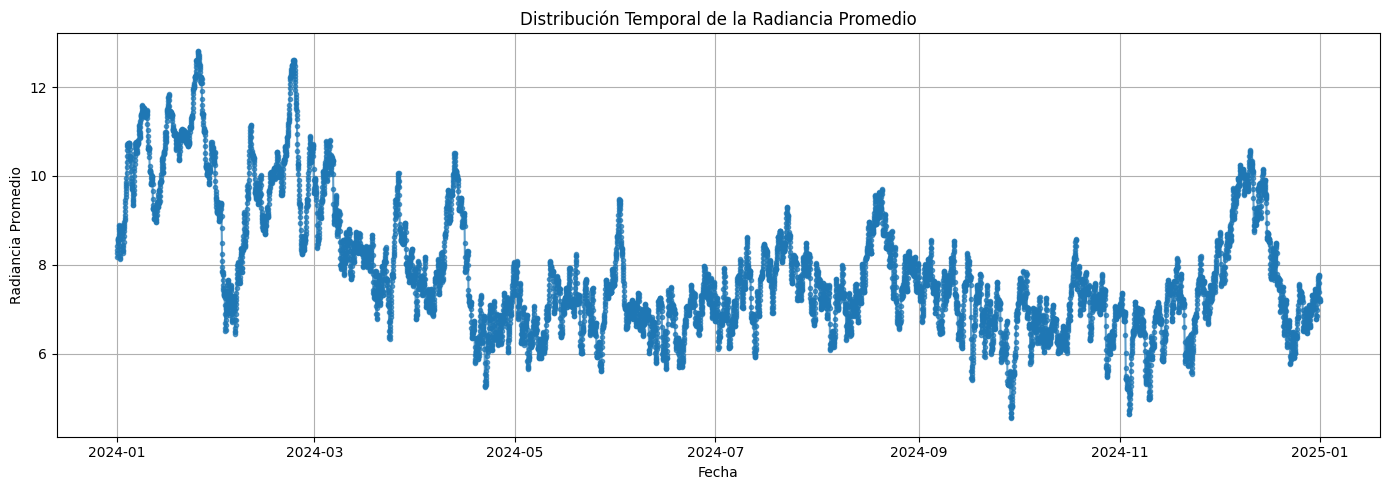

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(df_imagenes.index, df_imagenes['media'], marker='.', linestyle='-', alpha=0.7)
plt.title('Distribución Temporal de la Radiancia Promedio')
plt.xlabel('Fecha')
plt.ylabel('Radiancia Promedio')
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

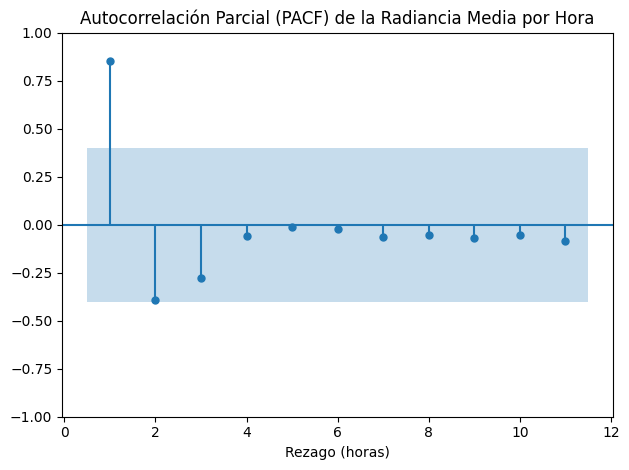

In [14]:
from statsmodels.graphics.tsaplots import plot_pacf

# Autocorrelación parcial para la media por hora
plt.figure(figsize=(8, 4))
plot_pacf(resumen_media_hora['media'], lags=11, method='ywm', zero=False)
plt.title('Autocorrelación Parcial (PACF) de la Radiancia Media por Hora')
plt.xlabel('Rezago (horas)')
plt.tight_layout()
plt.show()

* Línea temporal de la radiancia mínima

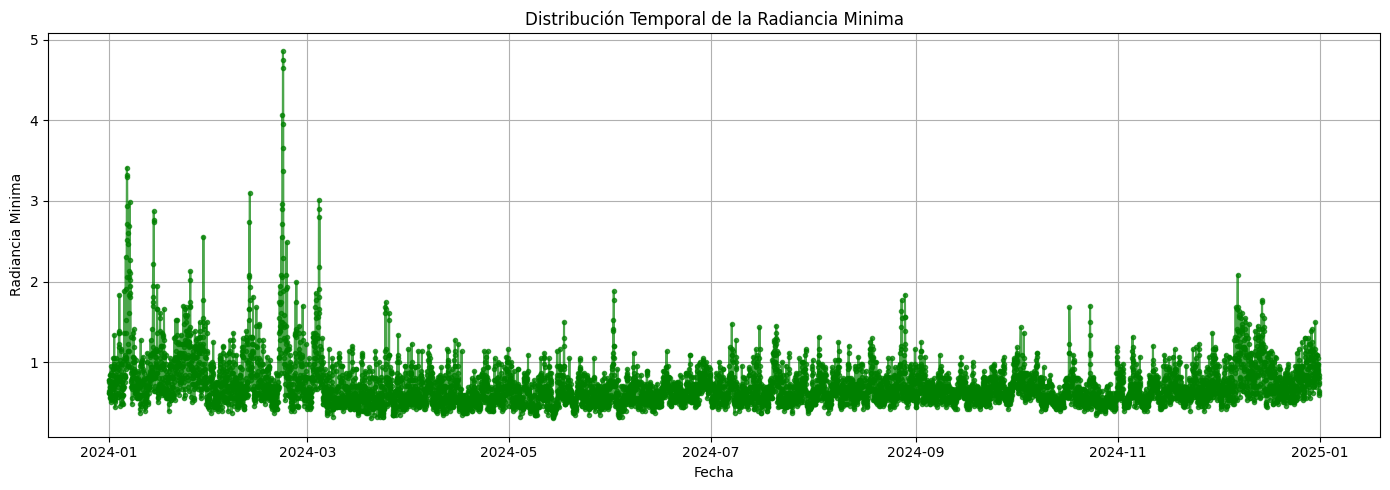

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(df_imagenes.index, df_imagenes['minimo'], marker='.', linestyle='-', alpha=0.7, color='green')
plt.title('Distribución Temporal de la Radiancia Minima')
plt.xlabel('Fecha')
plt.ylabel('Radiancia Minima')
plt.grid(True)
plt.tight_layout()
plt.show()

* Línea temporal de la radiancia máxima

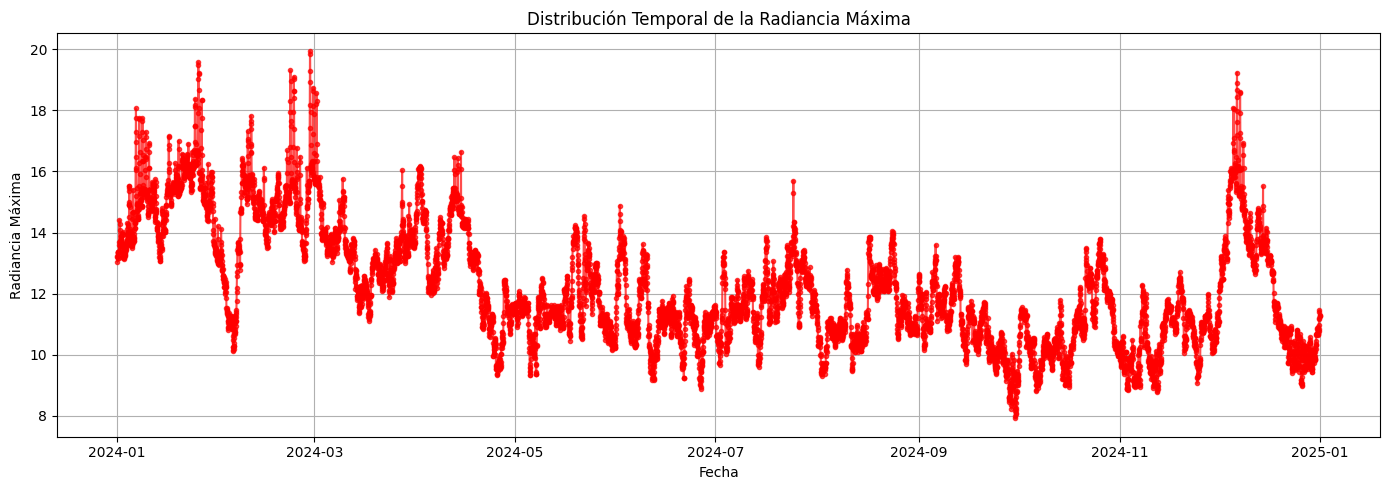

In [16]:
# Línea temporal de radiancia Máxima
plt.figure(figsize=(14, 5))
plt.plot(df_imagenes.index, df_imagenes['maximo'], marker='.', linestyle='-', alpha=0.7, color='red')
plt.title('Distribución Temporal de la Radiancia Máxima')
plt.xlabel('Fecha')
plt.ylabel('Radiancia Máxima')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4) Análisis de series de tiempo

Se realiza la descomposicion de la serie de tiempo empleando el modelo aditivo con un parametro period de 24 debido a la frecuencia de los datos. posteriormente se realizo el suavizado de la serie de tiempo mediante la tecnica del promedio movil simple.

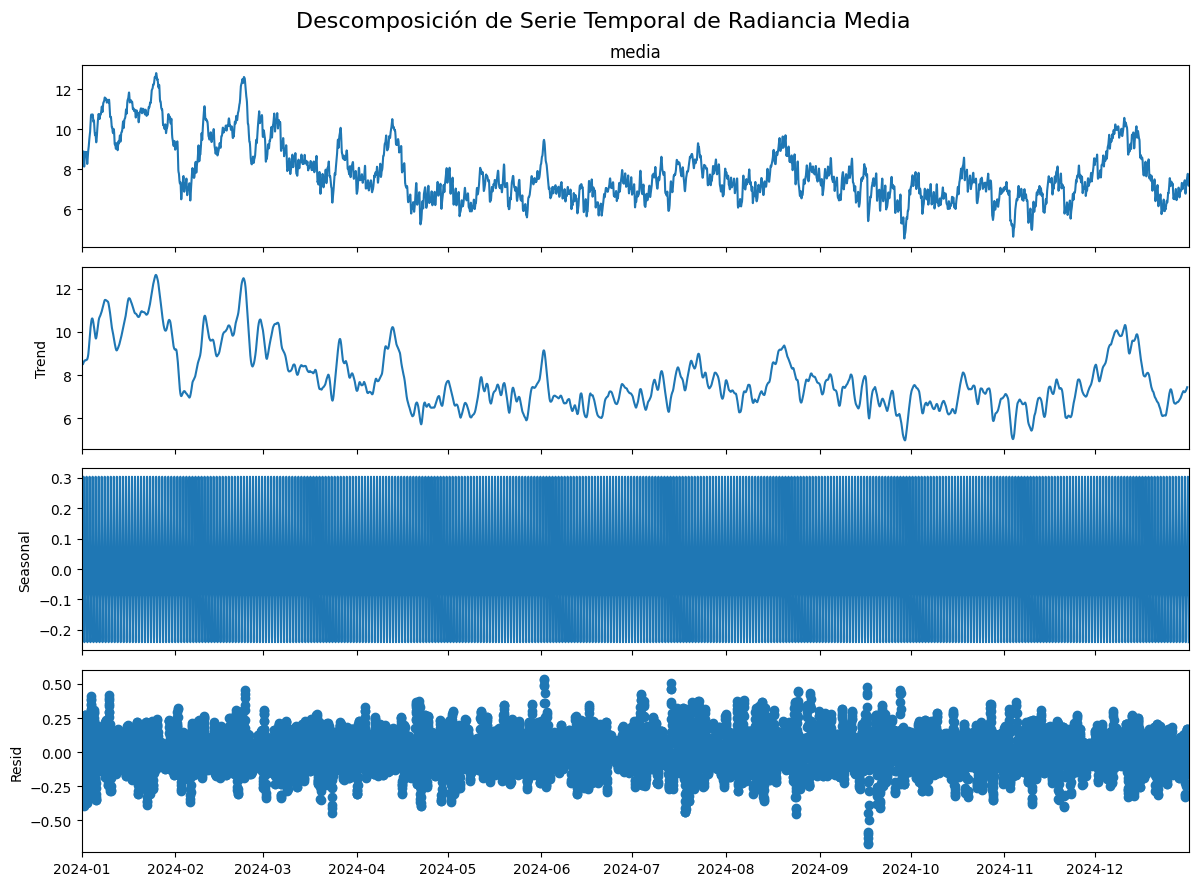

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Asegurar que la serie tenga frecuencia uniforme
# Resampleamos a una frecuencia horaria (puedes ajustar según tus datos)
serie_media = df_imagenes['media'].resample('h').mean()

# Rellenamos valores faltantes con interpolación (si hay huecos)
serie_media = serie_media.interpolate()

# Descomposición: modelo aditivo (puedes probar 'multiplicative' si tiene más sentido)
descomposicion = seasonal_decompose(serie_media, model='additive', period=24)  # 24 = diario si es por hora

# Graficar componentes
fig = descomposicion.plot()
fig.set_size_inches(12, 9)
fig.suptitle('Descomposición de Serie Temporal de Radiancia Media', fontsize=16)
plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

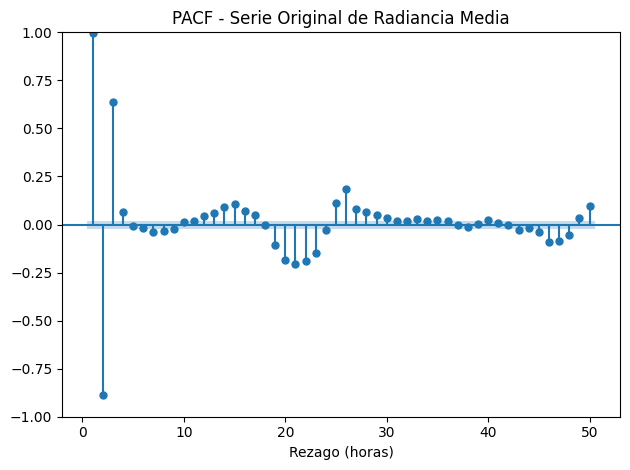

<Figure size 1000x400 with 0 Axes>

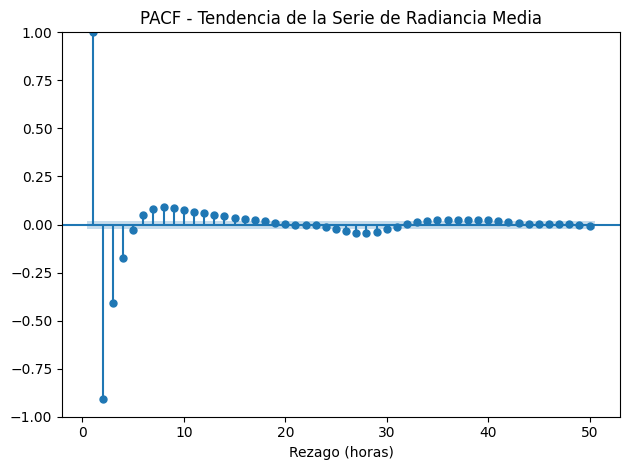

In [19]:
from statsmodels.graphics.tsaplots import plot_pacf

# Serie original (radiancia media horaria)
plt.figure(figsize=(10, 4))
plot_pacf(serie_media.dropna(), lags=50, method='ywm', zero=False)
plt.title('PACF - Serie Original de Radiancia Media')
plt.xlabel('Rezago (horas)')
plt.tight_layout()
plt.show()

# Tendencia extraída de la descomposición
tendencia = descomposicion.trend.dropna()

plt.figure(figsize=(10, 4))
plot_pacf(tendencia, lags=50, method='ywm', zero=False)
plt.title('PACF - Tendencia de la Serie de Radiancia Media')
plt.xlabel('Rezago (horas)')
plt.tight_layout()
plt.show()

* Promedio móvil simple

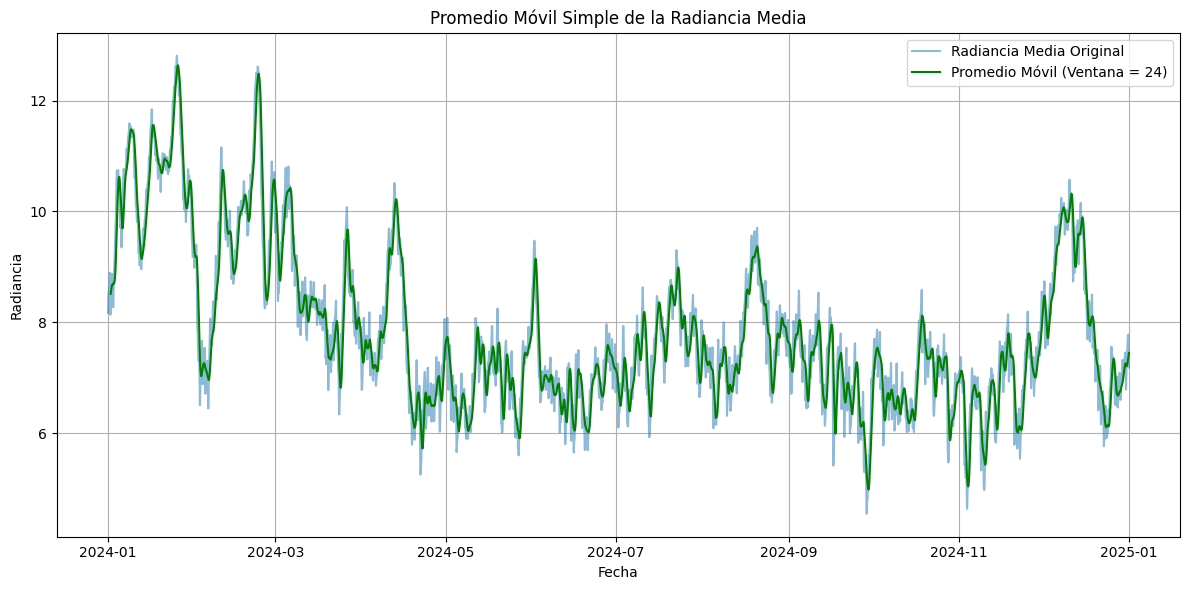

In [20]:
# 1. Resamplear la serie temporal a datos por hora
serie_media = df_imagenes['media'].resample('h').mean()

# 2. Rellenar valores faltantes si es necesario
serie_media = serie_media.interpolate()

# 3. Aplicar promedio móvil simple con una ventana de 24 (1 día si los datos son horarios)
ventana = 24
media_movil = serie_media.rolling(window=ventana).mean()

# 4. Graficar
plt.figure(figsize=(12, 6))
plt.plot(serie_media, label='Radiancia Media Original', alpha=0.5)
plt.plot(media_movil, label=f'Promedio Móvil (Ventana = {ventana})', color='green')
plt.title('Promedio Móvil Simple de la Radiancia Media')
plt.xlabel('Fecha')
plt.ylabel('Radiancia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

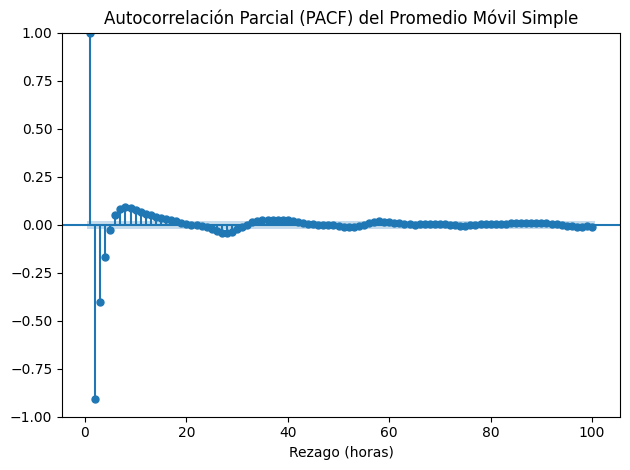

In [21]:
from statsmodels.graphics.tsaplots import plot_pacf

# Elimina los valores NaN del promedio móvil simple
media_movil_sin_nan = media_movil.dropna()

plt.figure(figsize=(8, 4))
plot_pacf(media_movil_sin_nan, lags=100, method='ywm', zero=False)
plt.title('Autocorrelación Parcial (PACF) del Promedio Móvil Simple')
plt.xlabel('Rezago (horas)')
plt.tight_layout()
plt.show()

# Conclusiones

El uso de archivos .npy y la construcción de un DataFrame con estadísticas clave (media, varianza, mínimo, máximo, mediana) permitió analizar grandes cantidades de imágenes satelitales de manera eficiente, evitando la sobrecarga de memoria. El análisis de autocorrelación aplicado a estas series temporales confirmó la presencia de patrones temporales consistentes que validan la robustez de esta metodología de procesamiento.

El análisis exploratorio mostró que la radiancia presenta variaciones significativas tanto a lo largo de los meses como de las horas del día, lo que evidencia la influencia de factores estacionales y horarios en la cobertura nubosa y la radiación solar. Estos patrones se ven reforzados por el análisis de autocorrelación, que reveló una fuerte dependencia temporal de corto plazo, particularmente en ciclos horarios consecutivos.

La descomposición aditiva y el uso del promedio móvil simple permitieron identificar tendencias, estacionalidades y fluctuaciones en la radiancia, facilitando la comprensión de los patrones temporales y la preparación de los datos para modelos predictivos. El estudio de autocorrelación proporcionó evidencia cuantitativa de estos patrones, mostrando una estructura de dependencia temporal que justifica el uso de técnicas de suavizado y descomposición.

El escalado de las imágenes entre 0 y 1 y la organización de los datos en series temporales proporcionan una base sólida para la aplicación de modelos de aprendizaje automático orientados a la predicción del movimiento de nubes y la optimización de plantas fotovoltaicas. La presencia de autocorrelación significativa en los datos valida esta aproximación, indicando que los valores pasados contienen información predictiva valiosa para pronosticar comportamientos futuros de la radiancia.